In [1]:
import pickle
import numpy as np
import pandas as pd

In [2]:
class LegacyUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        renames = {
            "pandas.indexes.base": "pandas.core.indexes.base",
            "pandas.indexes.numeric": "pandas.core.indexes.numeric",
            "pandas.indexes.range": "pandas.core.indexes.range",
            "pandas.indexes.multi": "pandas.core.indexes.multi",
            "pandas.indexes.category": "pandas.core.indexes.category",
            "pandas.indexes.datetimes": "pandas.core.indexes.datetimes",
            "pandas.indexes.period": "pandas.core.indexes.period",
            "pandas.indexes.timedeltas": "pandas.core.indexes.timedeltas",
        }
        module = renames.get(module, module)
        return super().find_class(module, name)

with open("data/raw/LSWMD.pkl", "rb") as f:
    df = LegacyUnpickler(f, encoding="latin1").load()

/var/folders/42/dqcm_7xd4pz6qhnbk1lrgcyr0000gn/T/ipykernel_28919/1173136058.py:17: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  df = LegacyUnpickler(f, encoding="latin1").load()


In [3]:
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")
print(f"Column names: {df.columns.tolist()}")
print("Data types of each column:")
print(df.dtypes)

Number of rows: 811457, Number of columns: 6
Column names: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']
Data types of each column:
waferMap           object
dieSize           float64
lotName            object
waferIndex        float64
trianTestLabel     object
failureType        object
dtype: object


In [4]:
pd.set_option('display.max_rows', 100)

df['failureType'] = df['failureType'].apply(
    lambda x: x[0][0] if isinstance(x, np.ndarray) and x.size > 0 else np.nan
)

print(df['failureType'].value_counts())
print(f"\nPercentage of wafers with no failure label: {(df['failureType'].isna().sum() / len(df)) * 100:.2f}%")

failureType
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64

Percentage of wafers with no failure label: 78.69%


In [8]:
wafer = df['waferMap'].iloc[0]
print(type(wafer))
print(wafer.shape)
print(np.unique(wafer))
print(wafer)

<class 'numpy.ndarray'>
(45, 48)
[0 1 2]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


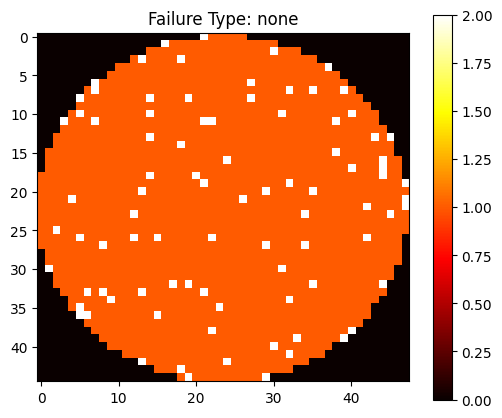

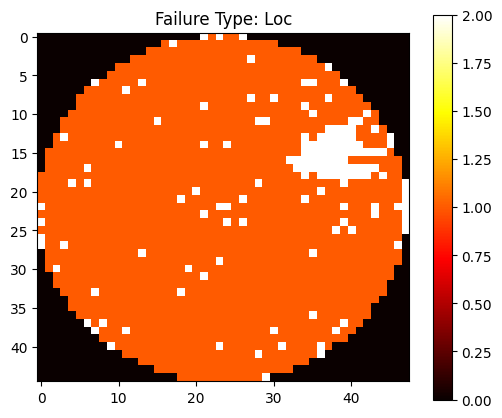

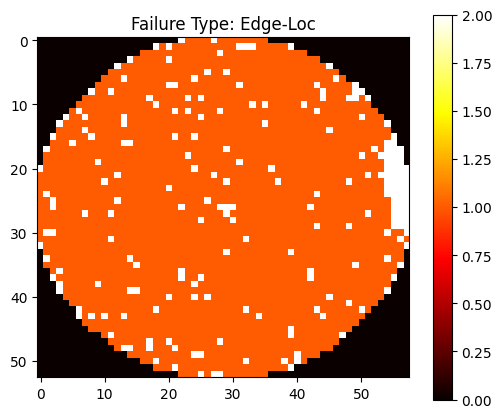

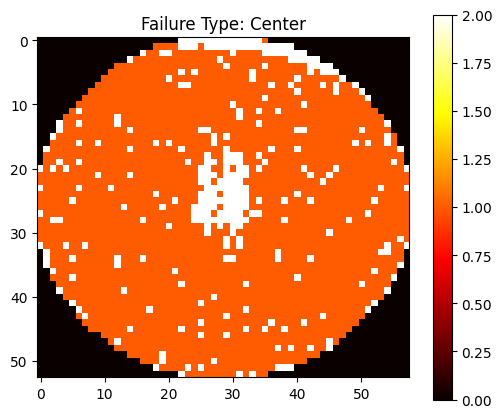

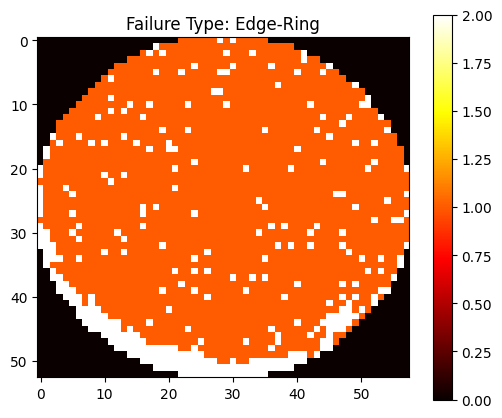

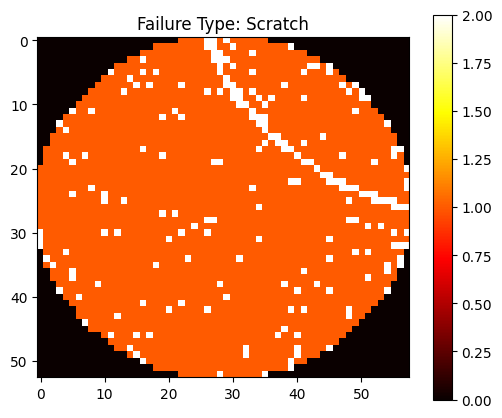

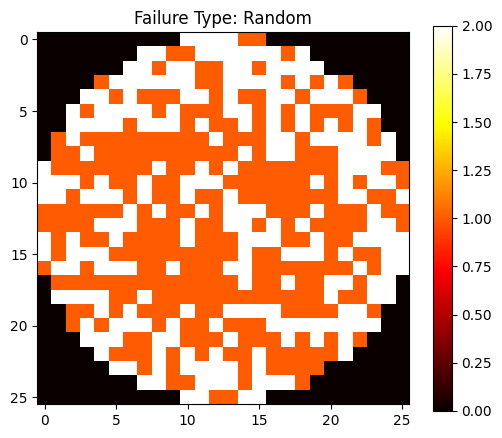

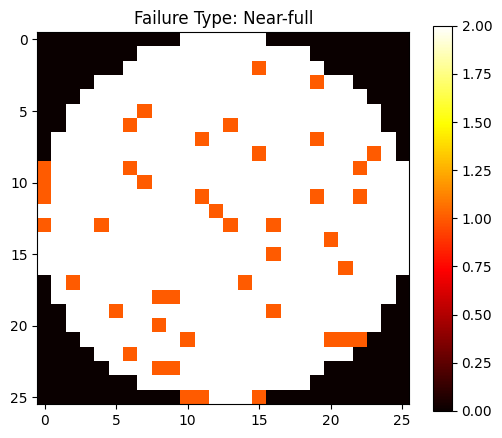

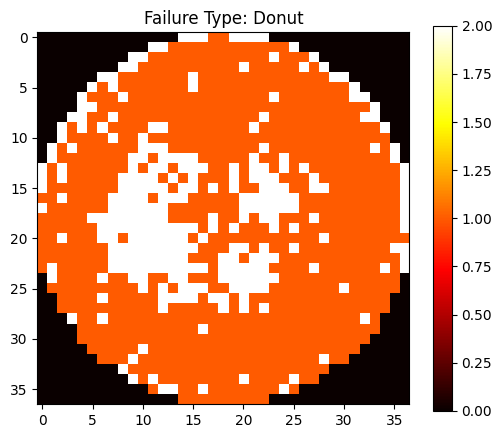

In [12]:
import matplotlib.pyplot as plt

for defect_type in df['failureType'].dropna().unique():
    sample = df[df['failureType'] == defect_type].iloc[0]
    plt.figure(figsize=(6, 5))
    plt.imshow(sample['waferMap'], cmap='hot', interpolation='nearest')
    plt.colorbar()
    plt.title(f"Failure Type: {defect_type}")
    plt.savefig(f"data/{defect_type}.png")
    plt.show()